In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# # Optional: Better plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [6]:
df = pd.read_csv("/content/feature_engineered_data.csv")

In [7]:
df.head()

,date,city,temperature_c,humidity_percent,electricity_units_kwh,household_size,income_level,power_outage_hours,year,month,day,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2022-01-31,0,29.7,46,14.24,5,1,1.30,2022,1,31,0,0,24.17,25.48,26.65,23.034286,22.247333
1,2022-02-01,3,31.7,39,25.43,3,2,1.22,2022,2,1,1,0,14.24,17.76,25.32,24.130000,22.251000
2,2022-02-02,3,28.3,79,24.70,4,2,2.02,2022,2,2,2,0,25.43,27.13,23.40,23.782857,22.294333
3,2022-02-03,1,32.5,56,10.78,8,0,1.04,2022,2,3,3,0,24.70,31.90,20.51,20.765714,21.970000
4,2022-02-04,0,21.2,83,15.03,2,2,0.48,2022,2,4,4,0,10.78,28.42,29.20,18.852857,21.497667


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df.set_index('date', inplace=True)

In [10]:
print(df.index)

DatetimeIndex(['2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03',
               '2022-02-04', '2022-02-05', '2022-02-06', '2022-02-07',
               '2022-02-08', '2022-02-09',
               ...
               '2026-01-30', '2026-01-31', '2026-02-01', '2026-02-02',
               '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06',
               '2026-02-07', '2026-02-08'],
              dtype='datetime64[ns]', name='date', length=1470, freq=None)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1470 entries, 2022-01-31 to 2026-02-08
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   city                   1470 non-null   int64  
 1   temperature_c          1470 non-null   float64
 2   humidity_percent       1470 non-null   int64  
 3   electricity_units_kwh  1470 non-null   float64
 4   household_size         1470 non-null   int64  
 5   income_level           1470 non-null   int64  
 6   power_outage_hours     1470 non-null   float64
 7   year                   1470 non-null   int64  
 8   month                  1470 non-null   int64  
 9   day                    1470 non-null   int64  
 10  day_of_week            1470 non-null   int64  
 11  is_weekend             1470 non-null   int64  
 12  lag_1                  1470 non-null   float64
 13  lag_7                  1470 non-null   float64
 14  lag_30                 1470 non-null  

In [12]:
data = df['electricity_units_kwh']

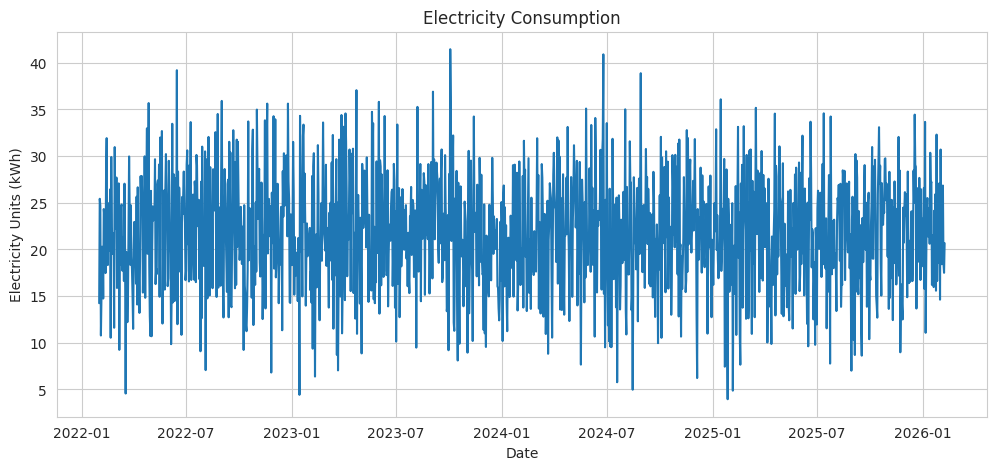

In [13]:
plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Electricity Units (kWh)")
plt.show()

In [14]:
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

In [15]:
print(train.shape)
print(test.shape)

(1176,)
(294,)


In [16]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [17]:
print(model_fit.summary())

                                 SARIMAX Results                                 
Dep. Variable:     electricity_units_kwh   No. Observations:                 1176
Model:                    ARIMA(5, 1, 0)   Log Likelihood               -3885.497
Date:                   Sun, 02 Aug 2026   AIC                           7782.995
Time:                           04:32:28   BIC                           7813.409
Sample:                       01-31-2022   HQIC                          7794.464
                            - 04-20-2025                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8595      0.028    -30.403      0.000      -0.915      -0.804
ar.L2         -0.7283      0.037    -19.429      0.000      -0.802      -0.655
ar.L3         -0.5756      0

In [18]:
predictions = model_fit.forecast(steps=len(test))

In [19]:
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 4.67494789021764
MSE : 31.900164797572387
RMSE: 5.6480230875565995


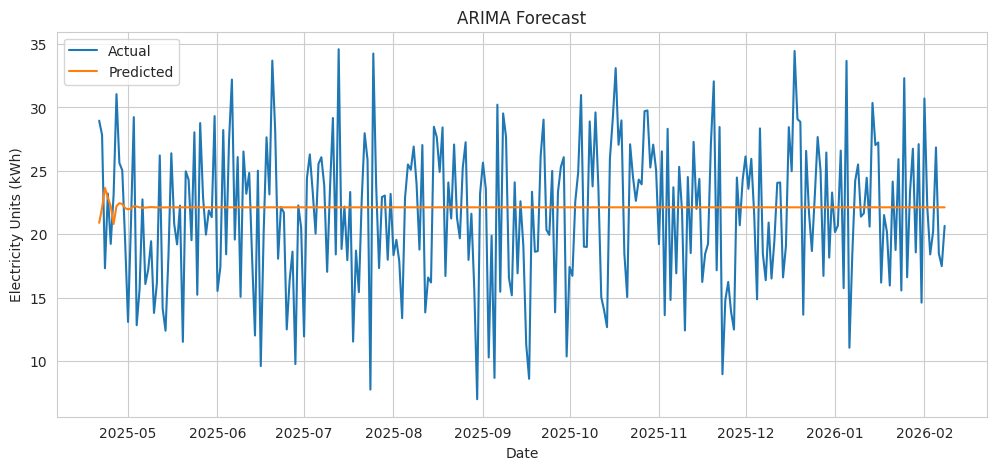

In [20]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted")

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Electricity Units (kWh)")
plt.legend()

plt.show()

In [21]:
results = pd.DataFrame({
    "Model":["ARIMA"],
    "MAE":[mae],
    "MSE":[mse],
    "RMSE":[rmse]
})

results.to_csv("arima_results.csv", index=False)

In [22]:
import pickle

with open("arima.pkl", "wb") as f:
    pickle.dump(model_fit, f)

In [23]:
from google.colab import files

files.download("arima.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>